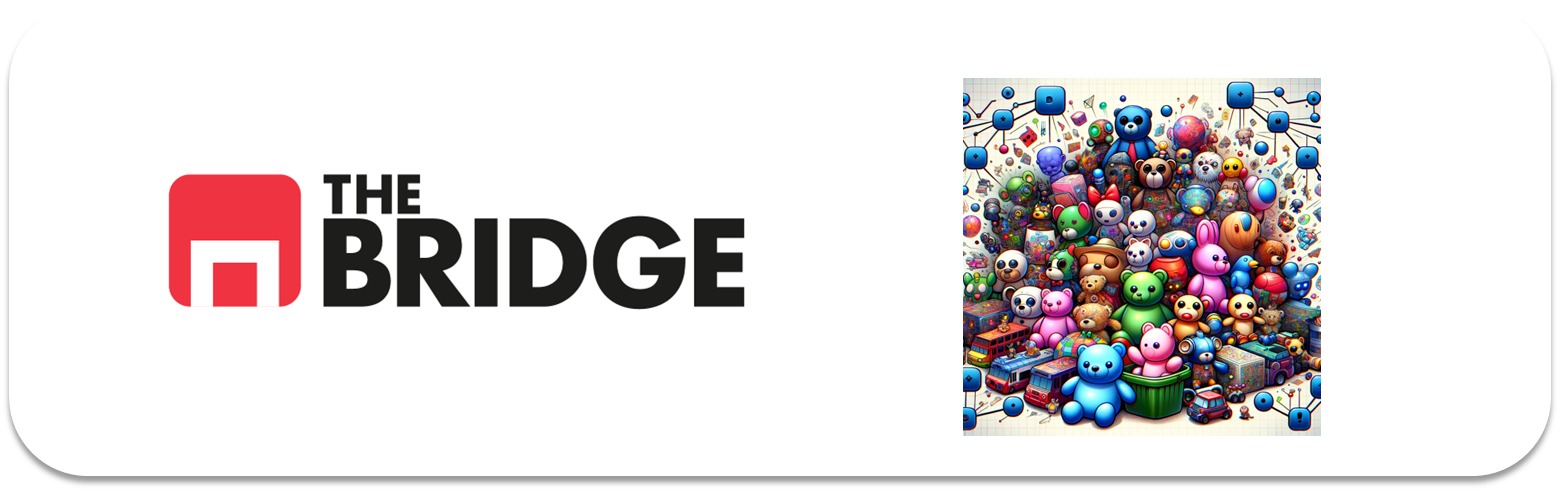

## PRACTICA OBLIGATORIA: **DBSCAN y Clustering Jerárquico**

* La práctica obligatoria de esta unidad consiste en un ejercicio de modelado no supervisado aplicado a clustering jerárquico y no jerárquico. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import linkage, dendrogram





### Parte I. Modelado

#### Descripción del problema.

En una planta de experimentación con nuevas bebidas energéticas están trabajando con diferentes mezclas de componentes para obtener posibles variedades de su producto estrella "NonstopU". El problema es que la fabricación de cada "prototipo" conlleva demasiado tiempo y las pruebas de sabores y de propiedades "non-stop" antisueño y antifatiga son costosas.  

En ese sentido quieren construir algún sistema de segmentación previa de mezclas sin probarlas solo indicando las cantidades de cada componente de la bebida. Tienen datos pero desgraciadamente de mezclas anteriores con diferentes medidas pero que por temas presupuestarios y de prioridad no se hicieron test con usuarios y potenciales clientes, es decir no tienen un target de capacidad antifatiga o de preferncia del usuario que puedas servirles para construir un clasificador clásico como han hecho otras veces.  

Han acudido a vosotros con la necesida de encontrar ese segmentador de posibles bebidas y con los datos de las mezclas no probadas anteriores por ver si vostros podéis ayudarles a encontrar algún tipo de segmentación que luego ello se encargarían de interpretar. No es requisito obligatorio pero les gustaría también poder establecer algún tipo de relación entre las segmentaciones (tipo cuales segmentos se "parecerían" más entre sí)

NOTA ORIENTATIVA: Los químicos no esperan que haya menos de 3 segmentos ni más de 5.  
NOTA OPERATIVA: El dataset con los datos que nos han dado los químicos está en "./data/empowering_drinks.csv"

**Se pide**: Construir al menos dos algoritmos de clustering (DBSCAN debe ser uno de ellos y el otro debería estar claro cual deberíamos usar dado el enunciado). Compararlos brevemente aunque sea meramente especulativo (¿Por qué es espculativo?)

**Se recomienda**: Visualizar las features dos a dos para escoger las mejores, no necesariamente hay que usar todas, ni tampoco quedarse en dos. Probar diferentes hiperparámetros en función de la nota orientativa y explicar porqué se han escogido los que finalmente se hayan escogido. 

Recuerda que el proceso es similar a lo que vimos en el otro tipo de aprendizaje:
1. Entender el problema
2. Cargar datos, visualizar.
3. MiniEDA: Selección de features
4. Tratamiento de Features.
5. Selección de modelos, selección de hiperparámetros
6. Entrenamiento, visualización de resultados.
7. Discusión de los mismos


In [2]:
df = pd.read_csv("./data/empowering_drinks.csv")

df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 1 columns):
 #   Column                                                        Non-Null Count  Dtype 
---  ------                                                        --------------  ----- 
 0   Azúcares|Vitamínas del grupo B|Cafeína|Ácido Cítrico|Taurina  153 non-null    object
dtypes: object(1)
memory usage: 1.3+ KB


,Azúcares|Vitamínas del grupo B|Cafeína|Ácido Cítrico|Taurina
count,153
unique,153
top,1.518612540989146|0.2320525409947431|1.0348189...
freq,1


In [2]:

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)


df = pd.read_csv("./data/empowering_drinks.csv")

print(df.shape)
display(df.head())
display(df.info())
display(df.describe().T)

(153, 1)


,Azúcares|Vitamínas del grupo B|Cafeína|Ácido Cítrico|Taurina
0,1.518612540989146|0.2320525409947431|1.0348189...
1,0.2462896270150547|-0.8279963232661995|0.73362...
2,0.1968790284141202|1.1093343596934533|1.215532...
3,1.6915496360924187|0.4879264047818666|1.466524...
4,0.2957002256159914|1.84040254194238|0.66335127...


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 1 columns):
 #   Column                                                        Non-Null Count  Dtype 
---  ------                                                        --------------  ----- 
 0   Azúcares|Vitamínas del grupo B|Cafeína|Ácido Cítrico|Taurina  153 non-null    object
dtypes: object(1)
memory usage: 1.3+ KB


None

,count,unique,top,freq
Azúcares|Vitamínas del grupo B|Cafeína|Ácido Cítrico|Taurina,153,153,1.518612540989146|0.2320525409947431|1.0348189...,1


In [3]:

df = df.iloc[:, 0].str.split("|", expand=True)


df.columns = ["azucares", "vitaminas_b", "cafeina", "acido_citrico", "taurina"]


df = df.apply(pd.to_numeric)

df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   azucares       153 non-null    float64
 1   vitaminas_b    153 non-null    float64
 2   cafeina        153 non-null    float64
 3   acido_citrico  153 non-null    float64
 4   taurina        153 non-null    float64
dtypes: float64(5)
memory usage: 6.1 KB


In [3]:
# Nulos
print("Valores nulos por columna:")
display(df.isna().sum())

# Duplicados
print("Filas duplicadas:", df.duplicated().sum())

Valores nulos por columna:


Azúcares|Vitamínas del grupo B|Cafeína|Ácido Cítrico|Taurina    0
dtype: int64

Filas duplicadas: 0


In [4]:
df_num = df.select_dtypes(include=[np.number]).copy()

print("Columnas numéricas:")
print(df_num.columns.tolist())

Columnas numéricas:
[]


In [5]:
cols_to_drop = [col for col in df_num.columns if "id" in col.lower()]
df_num = df_num.drop(columns=cols_to_drop, errors="ignore")

In [7]:
print(df.shape)
print(df.columns.tolist())
print(df.dtypes)

df_num = df.select_dtypes(include=[np.number]).copy()

print("Columnas numéricas:", df_num.columns.tolist())
print(df_num.shape)

(153, 1)
['Azúcares|Vitamínas del grupo B|Cafeína|Ácido Cítrico|Taurina']
Azúcares|Vitamínas del grupo B|Cafeína|Ácido Cítrico|Taurina    object
dtype: object
Columnas numéricas: []
(153, 0)


In [9]:
df = pd.read_csv("./data/empowering_drinks.csv")
print(df.head())
print(df.dtypes)

  Azúcares|Vitamínas del grupo B|Cafeína|Ácido Cítrico|Taurina
0  1.518612540989146|0.2320525409947431|1.0348189...          
1  0.2462896270150547|-0.8279963232661995|0.73362...          
2  0.1968790284141202|1.1093343596934533|1.215532...          
3  1.6915496360924187|0.4879264047818666|1.466524...          
4  0.2957002256159914|1.84040254194238|0.66335127...          
Azúcares|Vitamínas del grupo B|Cafeína|Ácido Cítrico|Taurina    object
dtype: object


In [10]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
print(df.columns)

Index(['azúcares|vitamínas_del_grupo_b|cafeína|ácido_cítrico|taurina'], dtype='object')


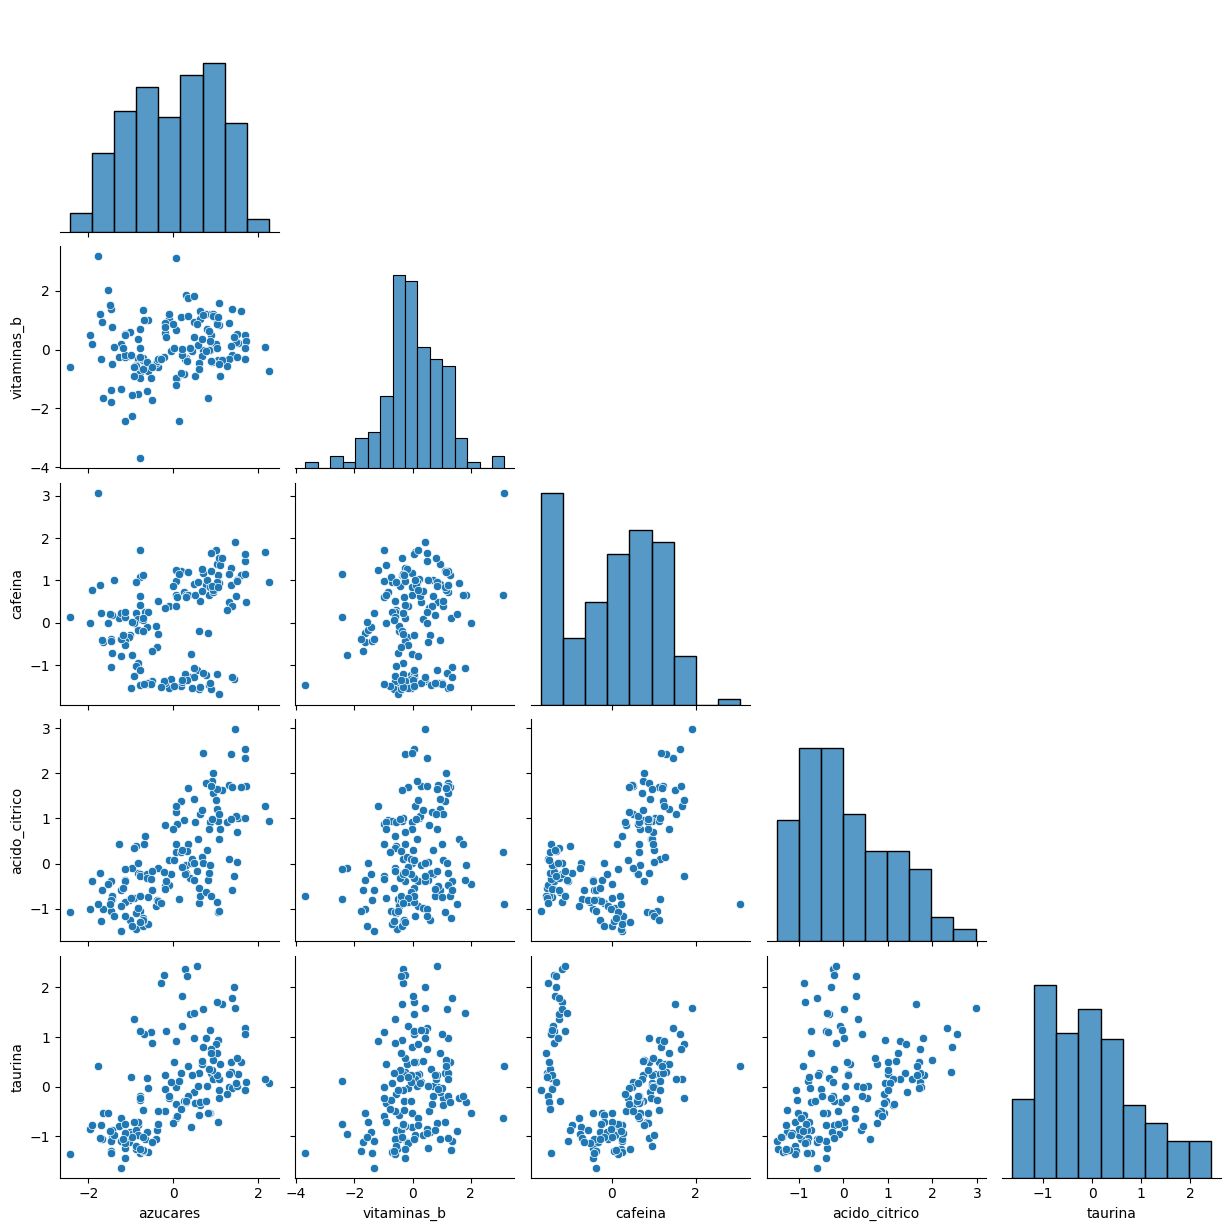

In [4]:
sns.pairplot(df, corner=True)
plt.show()

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

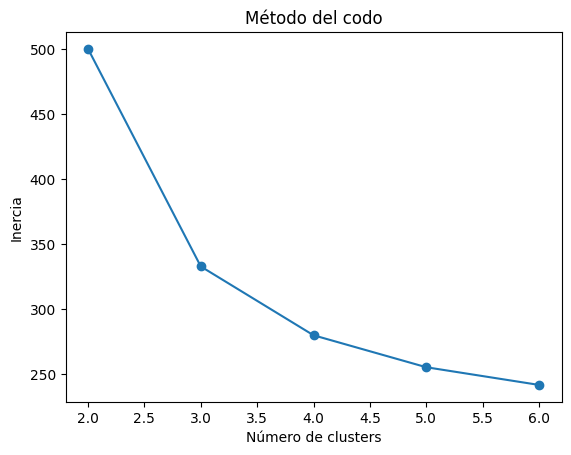

In [7]:


inertia = []
k_range = range(2, 7)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(k_range, inertia, marker='o')
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.title("Método del codo")
plt.show()

In [8]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters_kmeans = kmeans.fit_predict(X_scaled)

df["cluster_kmeans"] = clusters_kmeans

In [12]:


dbscan = DBSCAN(eps=1.2, min_samples=5)
clusters_dbscan = dbscan.fit_predict(X_scaled)

df["cluster_dbscan"] = clusters_dbscan

In [11]:


pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df["pca1"] = X_pca[:, 0]
df["pca2"] = X_pca[:, 1]

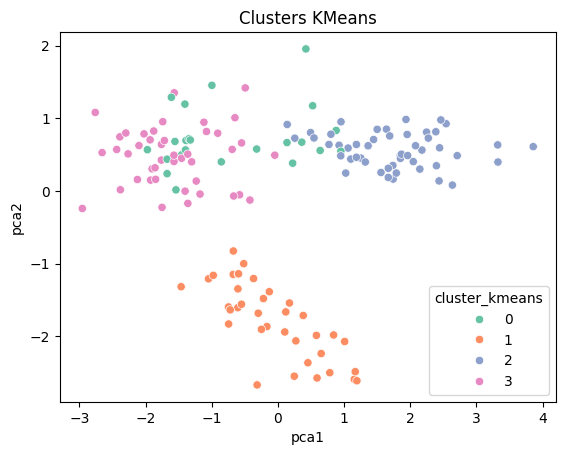

In [13]:
sns.scatterplot(data=df, x="pca1", y="pca2", hue="cluster_kmeans", palette="Set2")
plt.title("Clusters KMeans")
plt.show()

Se utiliza KMeans porque:
- Es un algoritmo basado en distancia (Euclídea), adecuado tras estandarizar los datos.
- Permite controlar el número de clusters, lo cual es útil dado que los químicos esperan entre 3 y 5 segmentos.
- Es eficiente y fácil de interpretar.

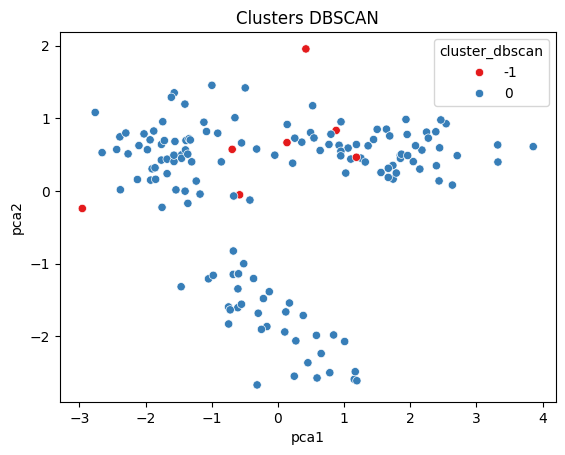

In [14]:
sns.scatterplot(data=df, x="pca1", y="pca2", hue="cluster_dbscan", palette="Set1")
plt.title("Clusters DBSCAN")
plt.show()

Se utiliza DBSCAN porque:
- No requiere especificar el número de clusters.
- Permite detectar ruido (outliers), lo cual puede ser útil en mezclas atípicas.
- Identifica clusters de forma arbitraria, no necesariamente esféricos.

In [15]:
from sklearn.metrics import silhouette_score

print("Silhouette KMeans:", silhouette_score(X_scaled, clusters_kmeans))

# DBSCAN solo si hay más de 1 cluster válido
if len(set(clusters_dbscan)) > 1:
    print("Silhouette DBSCAN:", silhouette_score(X_scaled, clusters_dbscan))

Silhouette KMeans: 0.35635171742398253
Silhouette DBSCAN: 0.21152462338861333


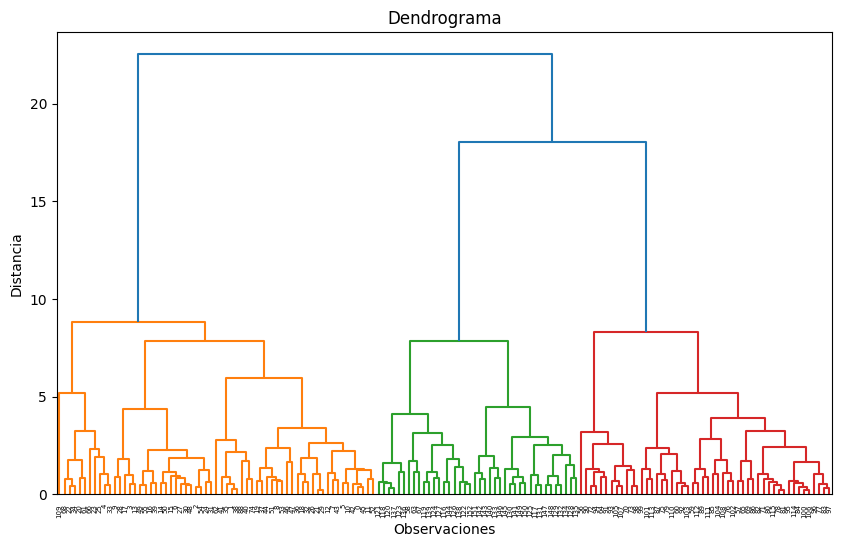

In [16]:
from scipy.cluster.hierarchy import linkage, dendrogram

linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(10,6))
dendrogram(linked)
plt.title("Dendrograma")
plt.xlabel("Observaciones")
plt.ylabel("Distancia")
plt.show()

El clustering jerárquico permite visualizar la relación entre las observaciones mediante un dendrograma.

A partir de este gráfico, podemos decidir el número de clusters observando los cortes más significativos en la distancia.

### Parte II. Nuevos experimentos

Los químicos están muy esperanzados con los modelos que les habéis mostrado y os pasan una lista de nuevos experimentos para que los clasifiquéis. Emplea uno de los modelos construidos, el que te resulte más sencillo, para segmentar los nuevos experimentos que puedes encontrar en "./data/new_experiments.csv"

In [17]:
df_new = pd.read_csv("./data/new_experiments.csv")

# mismo preprocesado
df_new = df_new.iloc[:, 0].str.split("|", expand=True)
df_new.columns = ["azucares", "vitaminas_b", "cafeina", "acido_citrico", "taurina"]
df_new = df_new.apply(pd.to_numeric)

# escalar con el MISMO scaler
X_new_scaled = scaler.transform(df_new)

# predecir con KMeans
df_new["cluster"] = kmeans.predict(X_new_scaled)

df_new.head()

,azucares,vitaminas_b,cafeina,acido_citrico,taurina,cluster
0,1.481555,0.305159,1.366128,2.239039,0.731870,2
1,0.616869,0.890014,0.583034,0.312420,-0.665332,2
2,-1.680724,0.341713,-0.340615,-0.213021,-0.976782,0
3,-0.284874,-1.412851,-0.782361,-1.193845,-0.717240,3
4,-0.927212,0.634140,-1.565455,-0.085641,-0.522583,1


En conclusión, KMeans se muestra como el modelo más adecuado para segmentar las mezclas de bebidas, ya que permite obtener una estructura clara de grupos dentro del rango esperado por los químicos.

DBSCAN, aunque útil para detectar outliers, no logra identificar múltiples clusters significativos en este dataset.

### Parte III. EXTRA (Voluntario): 6 meses después...

La unidad de experimentación recibió un presupuesto adicional gracias a los modelos que les proporcionastes e hizo pruebas con cliente y obtuvo resultados como para clasificar cada bebida en terminos de "energización" en tres niveles (1, media; 2, media-alta, 3, alta). El resultado de los mismos está en el fichero adecuado en el directorio data y alineado con los experimentos iniciales y al final con los nuevos experimentos de la parte anterior.

Evalua la segmentación de los modelos creados en la primera parte.